# Physiological Sepsis Phenotyping with Deep Consensus Clustering

In [1]:
## Section 1: Install Dependencies (Uncomment if running on Colab)
# !pip install umap-learn scikit-learn torch seaborn

## Section 2: Import Libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import umap
import seaborn as sns
import matplotlib.pyplot as plt

/ihome/mladi/choudhar/.local/lib/python3.10/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 2.2.6)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/ihome/crc/install/pytorch/2.0.1/python3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/ihome/crc/install/pytorch/2.0.1/python3.10/lib/python3.10/runpy.py", line 86, in _run_code
  

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:





df_Sepsis_latest_wTarget = pd.read_csv('Data_folder/df_step2_TS_pitts_s3_MEDIANimp_physiomarkers_2016-2022_wTargets_v7.csv')
#df_allFIN = pd.read_csv('Data_folder/df_step2_TS_pitts_s3_phenotypePredictedSegments_v5.csv')


df_presepsis_5min = df_Sepsis_latest_wTarget[df_Sepsis_latest_wTarget.segmentID==0]
df_presepsis_5min.reset_index(inplace=True, drop=True)
df_presepsis_5min

In [ ]:
X = df_presepsis_5min.loc[:,'T_rr_ms':'resp_rate_Bpm'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Deep Clustering With Consensus Representations (DECCS) - ICDM 2022

DECCS - Deep Embedded Clustering with Consensus representationS

### Ref: https://gitlab.cs.univie.ac.at/lukas/deccs

https://arxiv.org/abs/2210.07063, 

https://ieeexplore.ieee.org/document/10027597

In [4]:
X = df_presepsis_5min.loc[:,'T_rr_ms':'resp_rate_Bpm'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
## Section 4: Define Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

## Section 5: Train Autoencoder (Shared for IDEC and DeepConsensus)
def train_autoencoder(model, data, epochs=50, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        inputs = torch.tensor(data, dtype=torch.float32)
        recon, _ = model(inputs)
        loss = criterion(recon, inputs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

In [6]:
input_dim = X_scaled.shape[1]
model = Autoencoder(input_dim=input_dim)
model = train_autoencoder(model, X_scaled)

In [9]:
## Section 6: IDEC Clustering
with torch.no_grad():
    _, latent = model(torch.tensor(X_scaled, dtype=torch.float32))
latent_np = latent.numpy()
kmeans = KMeans(n_clusters=4, random_state=42).fit(latent_np)
idec_labels = kmeans.labels_

In [10]:
pd.Series(idec_labels).value_counts()

1    552
2    414
0    356
3    323
Name: count, dtype: int64

In [11]:
## Section 7: DeepConsensus Clustering (Ensemble + Consensus)
n_models = 10
all_labels = np.zeros((X_scaled.shape[0], n_models))
for i in range(n_models):
    model_i = Autoencoder(input_dim=input_dim)
    model_i = train_autoencoder(model_i, X_scaled, epochs=30)
    with torch.no_grad():
        _, z_i = model_i(torch.tensor(X_scaled, dtype=torch.float32))
    z_i_np = z_i.numpy()
    kmeans_i = KMeans(n_clusters=4, random_state=i).fit(z_i_np)
    all_labels[:, i] = kmeans_i.labels_

co_matrix = np.zeros((X_scaled.shape[0], X_scaled.shape[0]))
for i in range(n_models):
    for j in range(X_scaled.shape[0]):
        for k in range(X_scaled.shape[0]):
            co_matrix[j, k] += (all_labels[j, i] == all_labels[k, i])
co_matrix /= n_models

spectral = SpectralClustering(n_clusters=4, affinity='precomputed')
deepconsensus_labels = spectral.fit_predict(co_matrix)

In [12]:
pd.Series(deepconsensus_labels).value_counts()

2    639
0    467
3    377
1    162
Name: count, dtype: int64

IDEC Silhouette Score: 0.07650147750900077
IDEC DB Index: 2.836731205457313
IDEC Calinski-Harabasz Score: 146.56007511117048
DeepConsensus Silhouette Score: 0.10339818488528298
DeepConsensus DB Index: 2.3867983316618298
DeepConsensus Calinski-Harabasz Score: 160.4523049047732


/ihome/mladi/choudhar/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


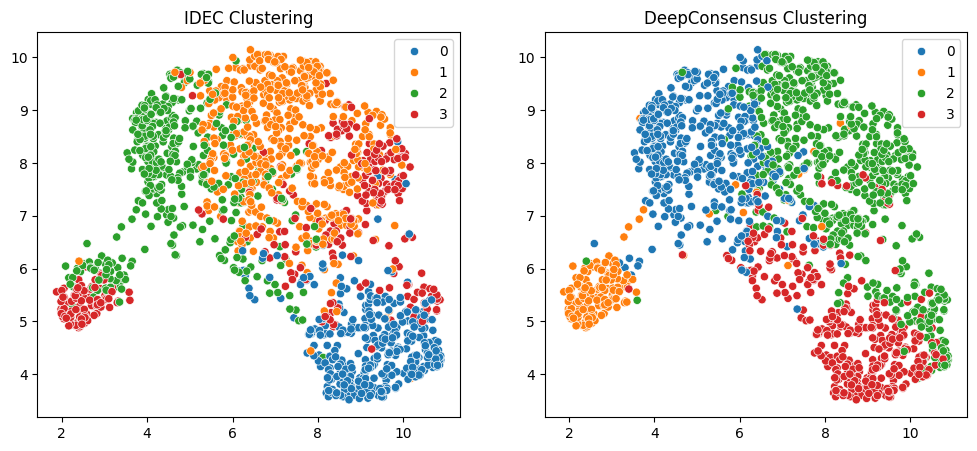

In [13]:
## Section 8: Evaluation
def evaluate_clusters(X, labels, name=""):
    print(f"{name} Silhouette Score:", silhouette_score(X, labels))
    print(f"{name} DB Index:", davies_bouldin_score(X, labels))
    print(f"{name} Calinski-Harabasz Score:", calinski_harabasz_score(X, labels))

evaluate_clusters(X_scaled, idec_labels, "IDEC")
evaluate_clusters(X_scaled, deepconsensus_labels, "DeepConsensus")

## Section 9: UMAP Visualization
reducer = umap.UMAP()
embedding = reducer.fit_transform(X_scaled)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=embedding[:,0], y=embedding[:,1], hue=idec_labels, palette='tab10')
plt.title("IDEC Clustering")
plt.subplot(1,2,2)
sns.scatterplot(x=embedding[:,0], y=embedding[:,1], hue=deepconsensus_labels, palette='tab10')
plt.title("DeepConsensus Clustering")
plt.show()